**Nike_vs_Adidas_Product_Segmentation **

Whenever people think of sneakers, Nike and Adidas often comes to mind. This debate has been happening for decades in the apparel space. Both giants have a large market cap and market share so it's no surprise that they are constantly battling to come out on top.

The objective of this project is to extract insights from teh data of men's and women's shoes, and grouping products together to identify similarities and differences between the product range of these brands.



**Data Description**
The dataset consists of 3268 products from Nike and Adidas with features of information including their ratings, discount, sales,price, product name, and the number of reviews

Product Name: Name of the product

Product ID: ID of the product

Listing Price: Listed price of the product

Sale Price: Sale price of the product

Discount: Percentage of discount on the product

Brand: Brand of the product

Rating: Rating of the product

Reviews: Number of reviews for the product

**Import Libraries**

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation and Reading
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the limit for the number of displayed column
pd.set_option("display.max_columns", None)
# Set the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# Compute distances
from scipy.spatial.distance import cdist

# To perform K-Means clustering and silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Visualize the elbow curve and silhouette
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [3]:

# load the dataset
data = pd.read_csv("/data_add_nik.csv")

In [4]:
data.shape

(3268, 8)

In [5]:
# View a random sample of the dataset
data.sample(n=10, random_state=1)

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
255,Women's adidas Originals POD-S3.1 Shoes,CG6188,13999,6999,50,Adidas ORIGINALS,3.3,8
1551,Men's adidas Originals Superstar Pure Shoes,FV3013,11999,11999,0,Adidas ORIGINALS,3.9,10
1352,Men's adidas Originals Superstar Shoes,FV2806,7999,7999,0,Adidas ORIGINALS,4.4,42
1060,Men's adidas Football Nemeziz 19.3 Indoor Shoes,F34411,5999,3599,40,Adidas SPORT PERFORMANCE,4.5,75
808,Men's adidas Sport Inspired Court 80s Shoes,EE9676,5999,3599,40,Adidas CORE / NEO,4.5,55
836,Men's adidas Running Stargon 1.0 Shoes,CM4935,4799,3839,20,Adidas CORE / NEO,3.5,21
2107,Men's adidas Originals Yung-96 Chasm Shoes,EE7238,7999,4799,40,Adidas ORIGINALS,3.0,62
3002,Nike SB Air Max Stefan Janoski 2,AQ7477-009,0,9995,0,Nike,2.6,11
2329,Men's adidas Originals Rivalry Low Shoes,FV4287,10999,10999,0,Adidas ORIGINALS,2.8,8
602,Men's adidas Sport Inspired Lite Racer RBN Shoes,F36642,5599,3919,30,Adidas CORE / NEO,3.0,56


In [6]:
df = data.copy()

In [7]:
# Fix the column names
df.columns = [c.replace(" ", "_") for c in df.columns]

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Name   3268 non-null   object 
 1   Product_ID     3268 non-null   object 
 2   Listing_Price  3268 non-null   int64  
 3   Sale_Price     3268 non-null   int64  
 4   Discount       3268 non-null   int64  
 5   Brand          3268 non-null   object 
 6   Rating         3268 non-null   float64
 7   Reviews        3268 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 204.4+ KB


In [9]:

df.drop("Product_ID", axis=1, inplace=True)

In [10]:

# Check for duplicate observations
df.duplicated().sum()

np.int64(117)

In [11]:
df = df[(~df.duplicated())].copy()

Now lets look at the summary of the data

In [12]:
df.describe()

,Listing_Price,Sale_Price,Discount,Rating,Reviews
count,3151.000000,3151.000000,3151.000000,3151.000000,3151.000000
mean,7045.960330,5983.166931,27.860997,3.285687,41.891146
std,4652.089511,4173.708897,22.442753,1.371611,31.283464
min,0.000000,449.000000,0.000000,0.000000,0.000000
25%,4599.000000,2999.000000,0.000000,2.600000,12.000000
50%,5999.000000,4599.000000,40.000000,3.600000,40.000000
75%,8999.000000,7799.000000,50.000000,4.400000,69.000000
max,29999.000000,36500.000000,60.000000,5.000000,223.000000


**Observations**

0 in the listing price indicates missing values

The average listing price is 7046

The average sale price is 5983

The average discount is 28%

The average rating is 3.3

The average number of reviews is 42

In [13]:
# Let's check how many products have a listing price of 0
(df.Listing_Price == 0).sum()

np.int64(336)

In [14]:
df[(df.Listing_Price == 0)]

,Product_Name,Listing_Price,Sale_Price,Discount,Brand,Rating,Reviews
2625,Nike Air Force 1 '07 Essential,0,7495,0,Nike,0.0,0
2626,Nike Air Force 1 '07,0,7495,0,Nike,0.0,0
2627,Nike Air Force 1 Sage Low LX,0,9995,0,Nike,0.0,0
2628,Nike Air Max Dia SE,0,9995,0,Nike,0.0,0
2629,Nike Air Max Verona,0,9995,0,Nike,0.0,0
...,...,...,...,...,...,...,...
3254,Nike Mercurial Vapor 13 Club MG,0,4995,0,Nike,0.0,0
3257,Air Jordan 5 Retro,0,15995,0,Nike,3.3,3
3260,Nike Tiempo Legend 8 Academy TF,0,6495,0,Nike,0.0,0
3262,Nike React Metcon AMP,0,13995,0,Nike,3.0,1


In [15]:
df[(df.Listing_Price == 0)].describe()

,Listing_Price,Sale_Price,Discount,Rating,Reviews
count,336.0,336.000000,336.0,336.000000,336.000000
mean,0.0,11203.050595,0.0,2.797619,8.261905
std,0.0,4623.825788,0.0,2.150445,19.708393
min,0.0,1595.000000,0.0,0.000000,0.000000
25%,0.0,7995.000000,0.0,0.000000,0.000000
50%,0.0,10995.000000,0.0,3.950000,1.000000
75%,0.0,13995.000000,0.0,4.700000,6.000000
max,0.0,36500.000000,0.0,5.000000,223.000000


There are 336 observations that have missing values in the listing price column
We see that the discount for the products with listing price 0 is 0.
So, we will replace the listing price with the corresponding sale price for those observations.


In [19]:

df.loc[(df.Listing_Price == 0), ["Listing_Price"]] = df.loc[
    (df.Listing_Price == 0), ["Sale_Price"]
].values


In [20]:

df.Listing_Price.describe()

,Listing_Price
count,3151.000000
mean,8240.573151
std,4363.018245
min,899.000000
25%,4999.000000
50%,7599.000000
75%,10995.000000
max,36500.000000


In [21]:

# Checking missing values
df.isna().sum()

,0
Product_Name,0
Listing_Price,0
Sale_Price,0
Discount,0
Brand,0
Rating,0
Reviews,0


**EDA**

In [22]:
# Function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

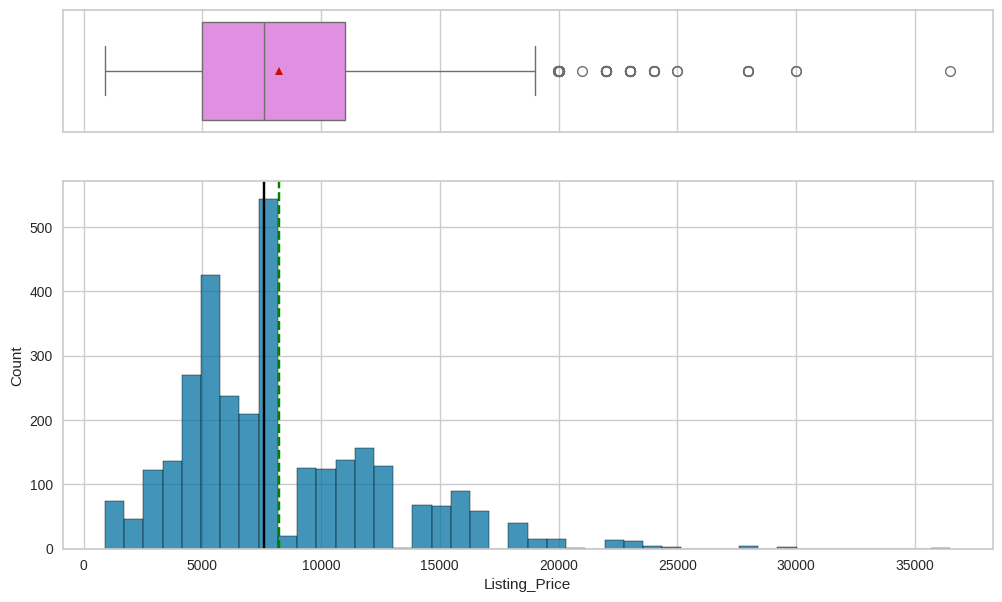

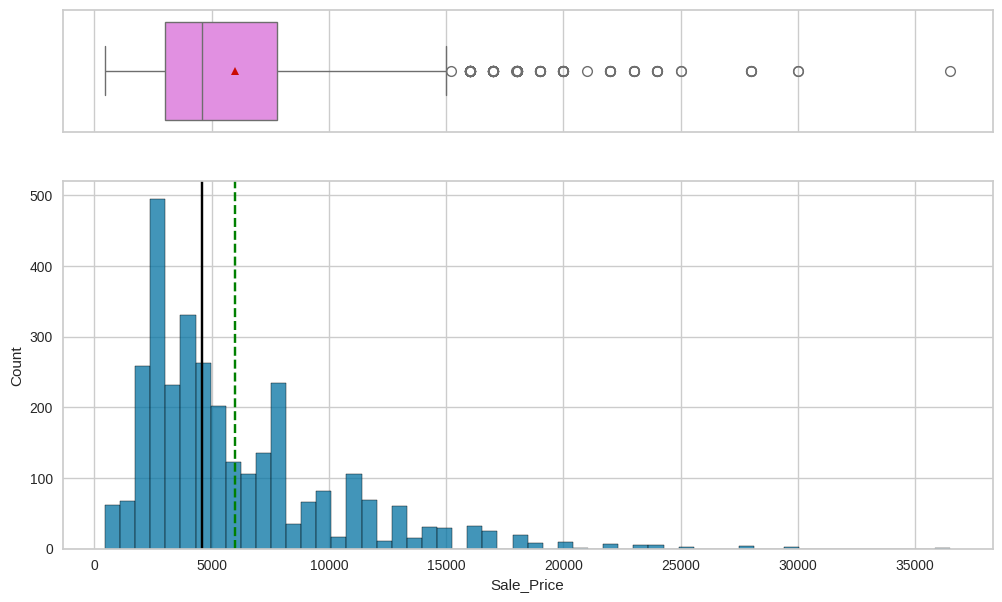

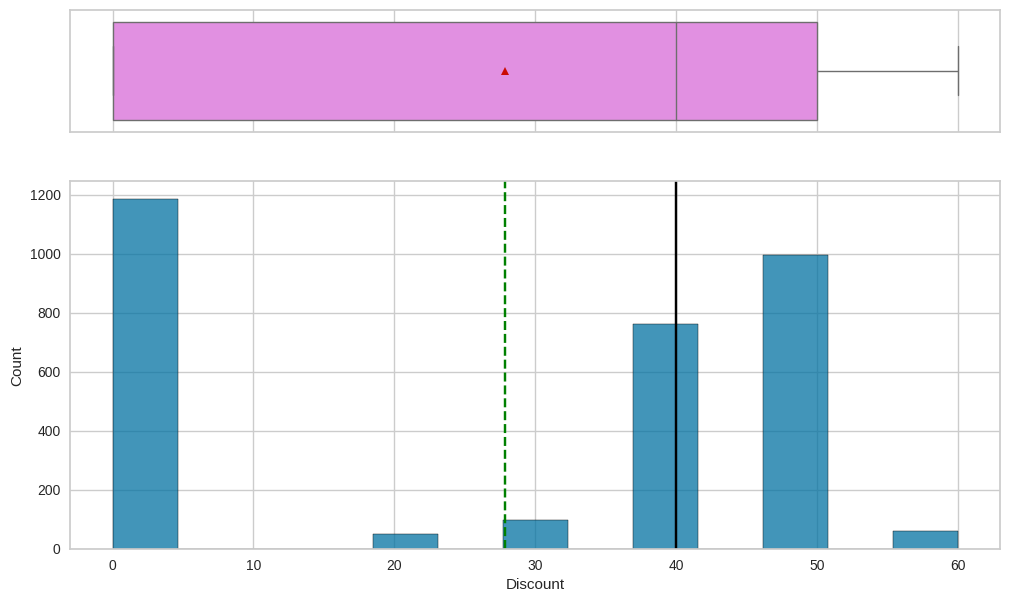

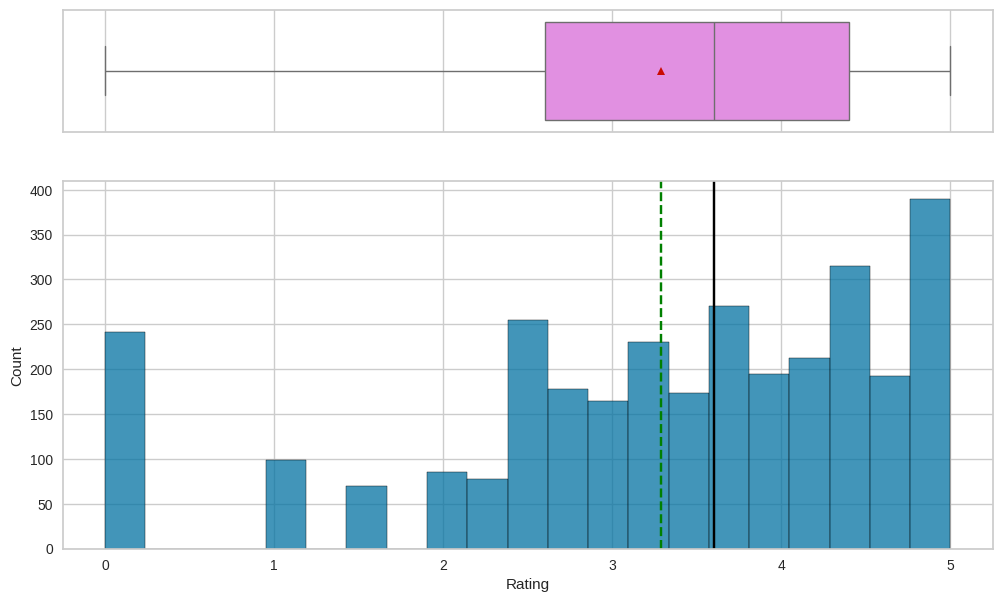

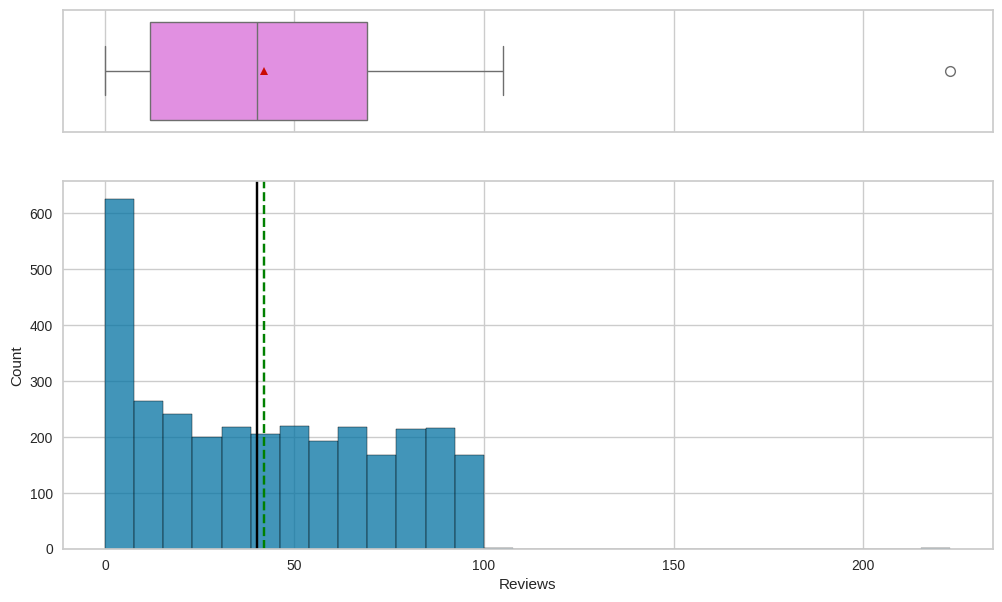

In [23]:
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

Observations:

Listing price and sale price have right-skewed distributions with upper outliers, which indicates the presence of very expensive products.
The maximum discount given is 60%.
Rating is left-skewed and most of the ratings are between 2.5 and 4.5.
The number of reviews is between 1 and 100, with an outlier value above 200

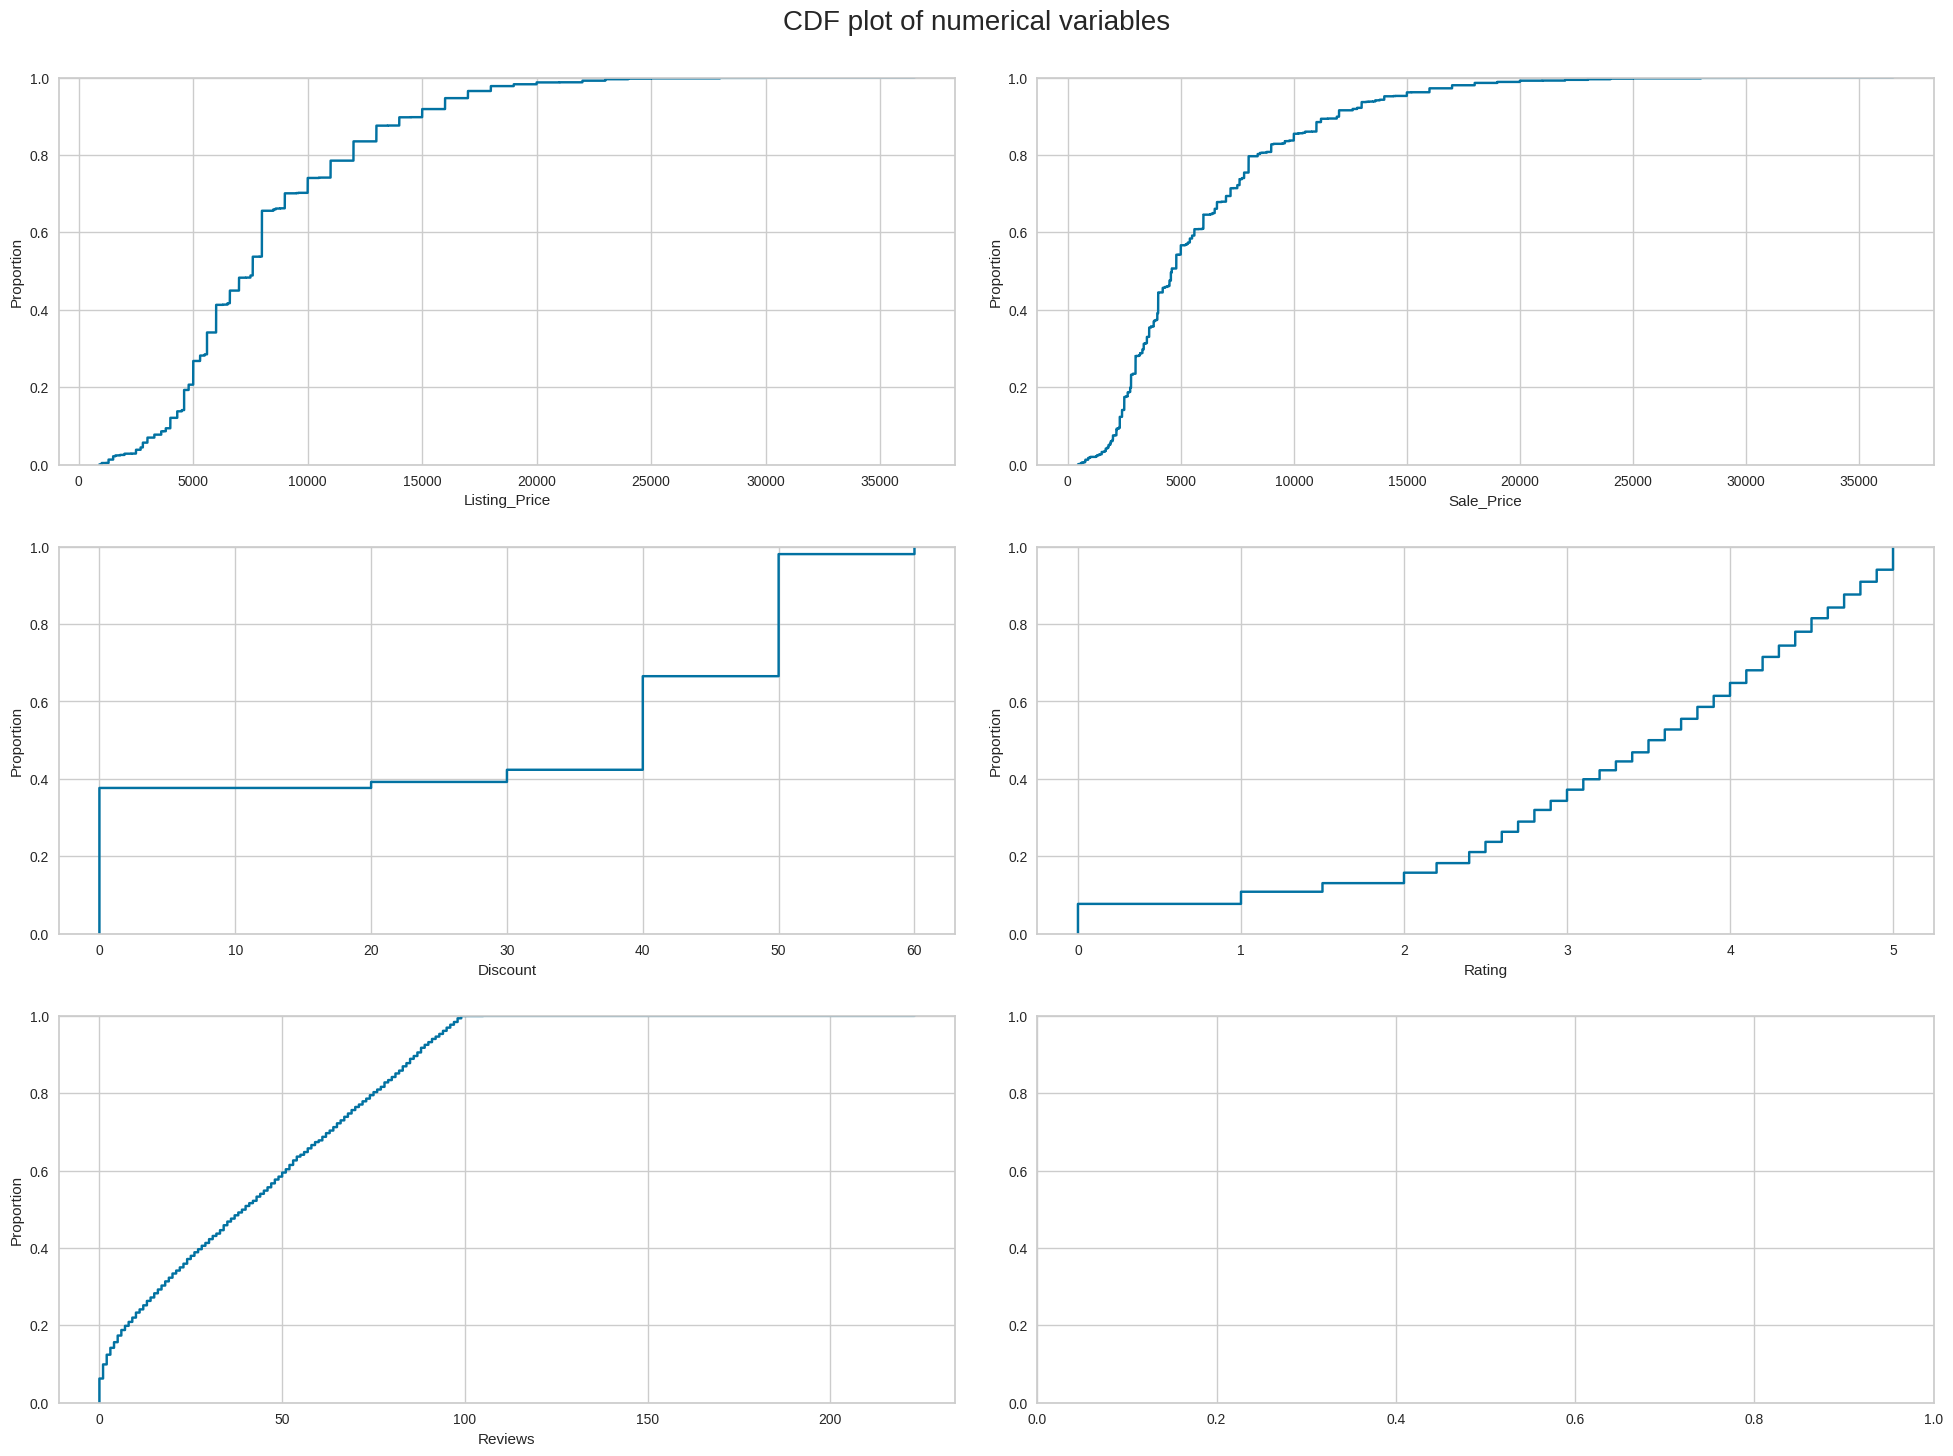

In [24]:

fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle("CDF plot of numerical variables", fontsize=20)
counter = 0
for ii in range(3):
    sns.ecdfplot(ax=axes[ii][0], x=df[num_col[counter]])
    counter = counter + 1
    if counter != 5:
        sns.ecdfplot(ax=axes[ii][1], x=df[num_col[counter]])
        counter = counter + 1
    else:
        pass

fig.tight_layout(pad=2.0)

90% of the products have listing prices less than 15000.
95% of the product have a sale price of less than 15000.
80% of the products have at least 50% discount or less than 50%.
50% off the products have a rating of 3.5 or less than 3.5.
Almost all products have 100 or fewer reviews.

In [25]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

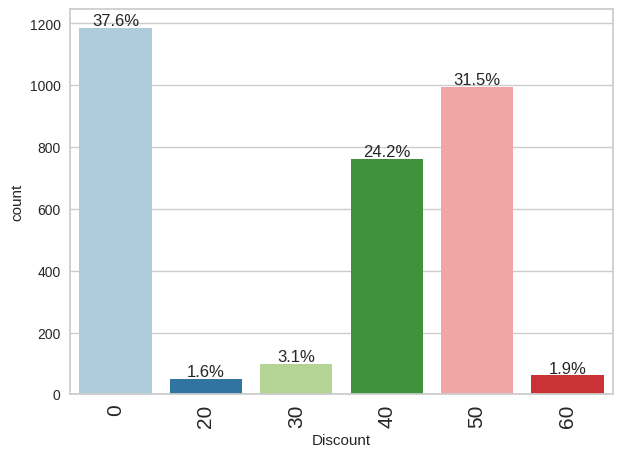

In [29]:

# Lets look at the discounts further
labeled_barplot(df, "Discount", perc=True)

**Observations:**


37.6% of products did not have any discounts
More than 50% of the products have 40-50% discount

**Bivariate Analysis**

Lets look for correlations

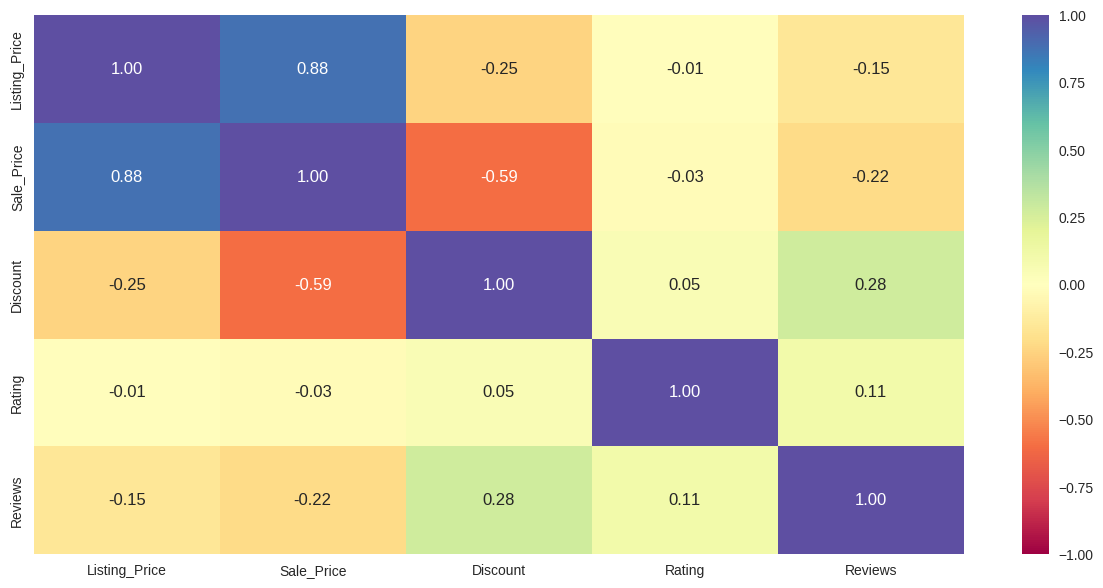

In [30]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations:**

The sale price and listing price are positvely correlated which is to be expected
Discount is negatively correlated with listing price or sales price, which indicates that expensive products either have fewer discounts or no discounts

**Data Preprocessing**

In [31]:
# variables for clustering
num_col

['Listing_Price', 'Sale_Price', 'Discount', 'Rating', 'Reviews']

In [32]:
# scale the dataset before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [33]:
# Create a dataframe of scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)
subset_scaled_df.head()

,Listing_Price,Sale_Price,Discount,Rating,Reviews
0,1.549271,0.363244,0.986622,1.104215,-0.028491
1,-0.147071,-0.523399,0.986622,0.010437,-0.571995
2,-1.660026,-1.290225,0.540973,-0.499993,-0.156374
3,-0.284613,-0.595289,0.986622,0.593785,-0.220316
4,-0.055377,-0.475472,0.986622,0.156274,0.962605


**K-means clustering**

Number of Clusters: 1 	Average Distortion: 2.0907211006458253
Number of Clusters: 2 	Average Distortion: 1.7119292934572274
Number of Clusters: 3 	Average Distortion: 1.5555561011052423
Number of Clusters: 4 	Average Distortion: 1.449794946742617
Number of Clusters: 5 	Average Distortion: 1.3082949577686984
Number of Clusters: 6 	Average Distortion: 1.2305226196899823
Number of Clusters: 7 	Average Distortion: 1.1690512026971218
Number of Clusters: 8 	Average Distortion: 1.143088261910772


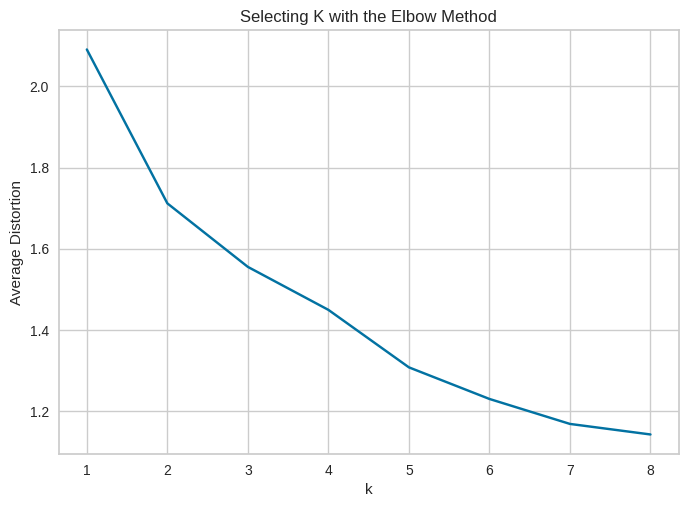

In [34]:
clusters =  range(1, 9)
meanDistortions = []

for k in clusters:
  model = KMeans(n_clusters = k)
  model.fit(subset_scaled_df)
  prediction = model.predict(subset_scaled_df)
  distortion = (
      sum(
          np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
      )
      / subset_scaled_df.shape[0]
  )

  meanDistortions.append(distortion)

  print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting K with the Elbow Method")
plt.show()

The best value for K seems to be 3 or 4, lets see based on the silhouette scores.

For n_clusters = 2, the silhouette score is 0.33462520494927556
For n_clusters = 3, the silhouette score is 0.3225101012925233
For n_clusters = 4, the silhouette score is 0.23612378289351282
For n_clusters = 5, the silhouette score is 0.2703997427723306
For n_clusters = 6, the silhouette score is 0.263500027858045
For n_clusters = 7, the silhouette score is 0.28303460254277646
For n_clusters = 8, the silhouette score is 0.27256731053234273
For n_clusters = 9, the silhouette score is 0.28184769361051465


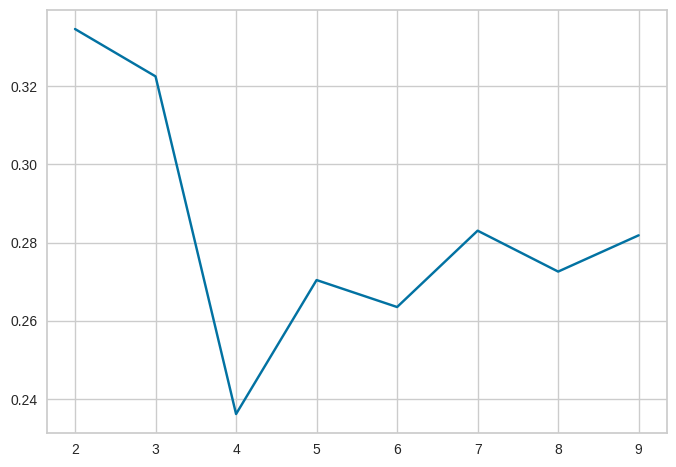

In [35]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
  clusterer = KMeans(n_clusters=n_clusters)
  preds = clusterer.fit_predict((subset_scaled_df))
  score = silhouette_score(subset_scaled_df, preds)
  sil_score.append(score)
  print("For n_clusters = {}, the silhouette score is {}".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

The Silhouette score is higher for 4, so we will choose 4 as k

In [36]:
kmeans = KMeans(n_clusters = 4, random_state = 0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=4, random_state=0)

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [37]:
# add kMeans cluster labels to original and scaled dataframes
df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

In [38]:
df.head()

,Product_Name,Listing_Price,Sale_Price,Discount,Brand,Rating,Reviews,K_means_segments
0,Women's adidas Originals NMD_Racer Primeknit S...,14999,7499,50,Adidas Adidas ORIGINALS,4.8,41,2
1,Women's adidas Originals Sleek Shoes,7599,3799,50,Adidas ORIGINALS,3.3,24,2
2,Women's adidas Swim Puka Slippers,999,599,40,Adidas CORE / NEO,2.6,37,2
3,Women's adidas Sport Inspired Questar Ride Shoes,6999,3499,50,Adidas CORE / NEO,4.1,35,2
4,Women's adidas Originals Taekwondo Shoes,7999,3999,50,Adidas ORIGINALS,3.5,72,2


**Cluster Profiling**

In [40]:
# numeric columns
cluster_profile = df.groupby("K_means_segments").mean(numeric_only=True)

In [41]:

cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Sale_Price"].count().values
)

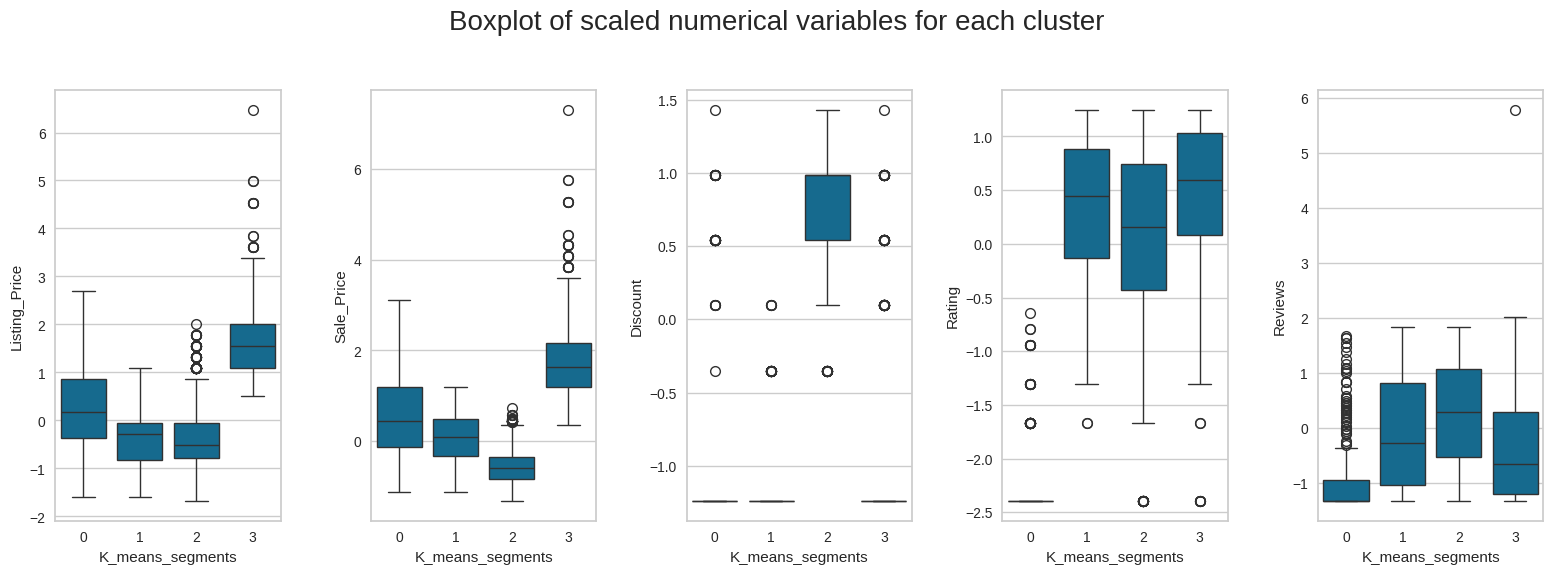

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

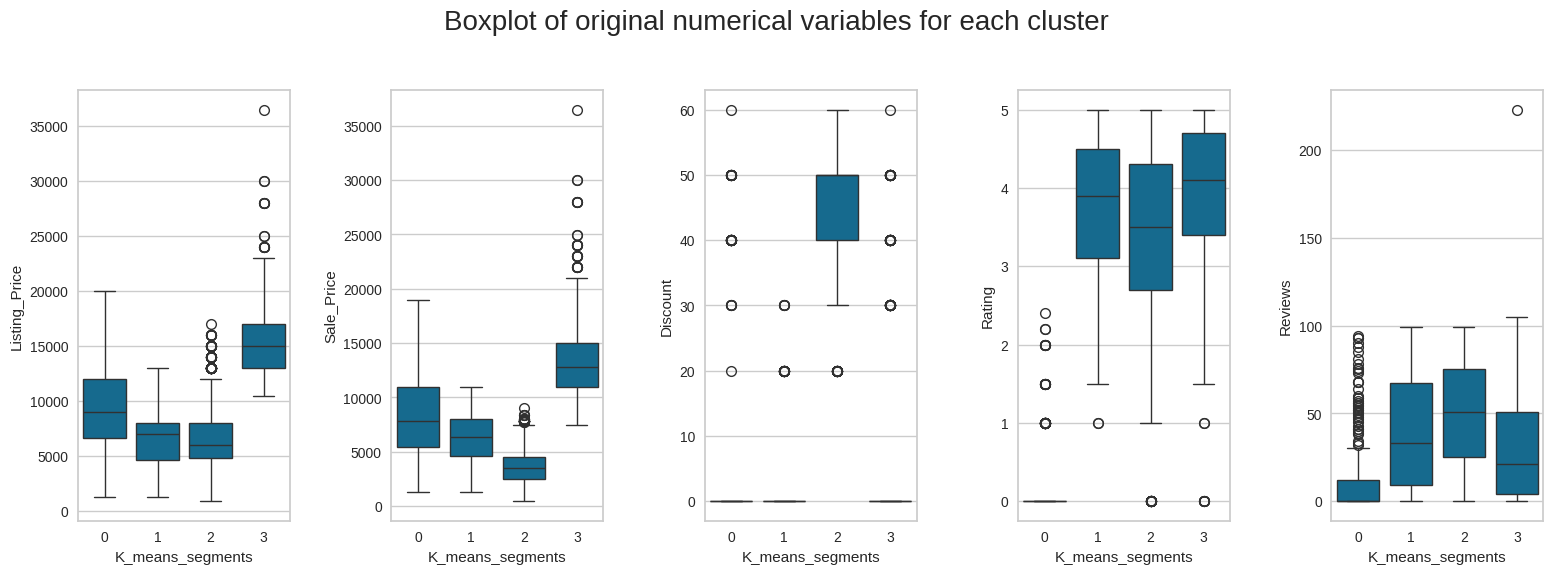

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_col[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

**Insights**
**Cluster 0**

Listing and sales price of products in this cluster suggest

that these are medium-range products.

Almost no discount is given to products in this cluster.

Products in this cluster have a low rating or no rating at all.

**Cluster 1**


The listing price of products in this cluster is similar to those in Cluster 2, but the sale price is comparatively higher as there are almost no discounts.
On average, 38 reviews are given to products in this cluster.

**Cluster 2**

Listing price is low for products in this cluster, and the sale price is lower, as there are heavier discounts on these products.
50% of the products have discounts between 30% to 40%.
More than 50% of products have a rating from 2.5 to 4.5 which indicates that customer satisfaction varies across products in this cluster.
On average, 50 reviews are given to products in this cluster.

**Cluster 3**

This cluster contains more expensive premium products, with an average listing price of approximately 15500.
Almost no discount is given to products in this cluster.
The median rating of this cluster is around 4 suggesting that customers are very satisfied with 50% of the products in this cluster.
Products in these clusters have got lesser reviews, which can be because these products are very expensive and fewer people buy them.
**Conclusions/Recommendations**
Cluster 3 consists of premium products, so focused marketing campaigns can be done to target customers with higher purchasing power.

Cluster 3 products can also be made available in showrooms situated in premium locations because people generally tend to buy premium products from showrooms.

Cluster 2 consists of products that are sold at higher discounts, so these might be the ones that are introduced in large quantity during festive sales (like Christmas, Black Friday, New Year, etc). This strategy can be continued with high inventory.

Cluster 0 and 1 consists of products with comparatively low and medium prices with almost no discount, so general marketing campaigns can be done for these to target the general public.